In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import analysis

d = np.load("../output/position_sims.npz", allow_pickle=True)
t_sys, fgnd = d["t_sys"], d["fgnd"]
names = [str(n) for n in d["names"]]
freqs = d["freqs_mhz"]
times_jd = d["times_jd"]
lst_hours = (times_jd - times_jd[0]) * 24.0
T_GND, T_RCVR = float(d["t_ground"]), float(d["t_receiver"])
print(t_sys.shape, fgnd.shape, "fgnd_nominal mean", fgnd[0].mean())

(19, 1436, 201) (19, 201) fgnd_nominal mean 0.5540062137318302


In [2]:
MODE = "uncorrected"   # "uncorrected" | "oracle" | "miscorrected"
delta = analysis.delta_waterfall(t_sys, fgnd, MODE, T_GND, T_RCVR)
stats = analysis.summary_stats(delta)
for nm, rms, mx in zip(names, stats["rms"], stats["max"]):
    print(f"{nm:10s}  RMS {rms:9.4g} K   max {mx:9.4g} K")

nominal     RMS         0 K   max         0 K
x_m_0p1     RMS     0.031 K   max     0.476 K
x_p_0p1     RMS   0.06931 K   max    0.9532 K
x_m_1       RMS    0.3572 K   max     5.358 K
x_p_1       RMS    0.3352 K   max     5.202 K
x_m_10      RMS     3.888 K   max     58.48 K
x_p_10      RMS     4.452 K   max      65.8 K
y_m_0p1     RMS  0.009182 K   max   0.09112 K
y_p_0p1     RMS   0.01051 K   max    0.1071 K
y_m_1       RMS   0.08096 K   max    0.7823 K
y_p_1       RMS   0.08349 K   max    0.9009 K
y_m_10      RMS    0.7815 K   max      5.08 K
y_p_10      RMS    0.8846 K   max     5.696 K
z_m_0p1     RMS    0.1015 K   max    0.9453 K
z_p_0p1     RMS    0.1012 K   max    0.9454 K
z_m_1       RMS     1.016 K   max     9.455 K
z_p_1       RMS      1.01 K   max     9.471 K
z_m_10      RMS     10.34 K   max     94.43 K
z_p_10      RMS     9.928 K   max     94.68 K


/tmp/ipykernel_673387/2045216086.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig("fig_spec_curve.pdf"); fig.show()


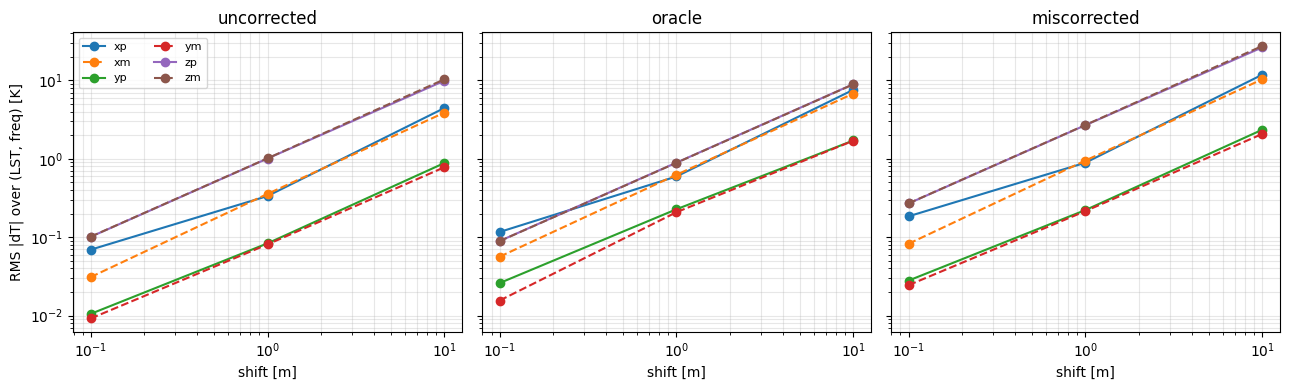

In [3]:
def s_for(axis, sign, mode):
    dl = analysis.delta_waterfall(t_sys, fgnd, mode, T_GND, T_RCVR)
    st = analysis.summary_stats(dl)
    mags = [0.1, 1.0, 10.0]
    tags = {0.1: "0p1", 1.0: "1", 10.0: "10"}
    return mags, [st["rms"][names.index(f"{axis}_{sign}_{tags[m]}")] for m in mags]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax_i, mode in zip(axes, analysis.MODES):
    for axis in "xyz":
        for sign, ls in [("p", "-"), ("m", "--")]:
            mags, s = s_for(axis, sign, mode)
            ax_i.loglog(mags, s, ls, marker="o", label=f"{axis}{sign}")
    ax_i.set_title(mode); ax_i.set_xlabel("shift [m]"); ax_i.grid(True, which="both", alpha=.3)
axes[0].set_ylabel("RMS |dT| over (LST, freq) [K]")
axes[0].legend(fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig("fig_spec_curve.pdf"); fig.show()

/tmp/ipykernel_673387/964098015.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig("fig_reductions.pdf"); fig.show()


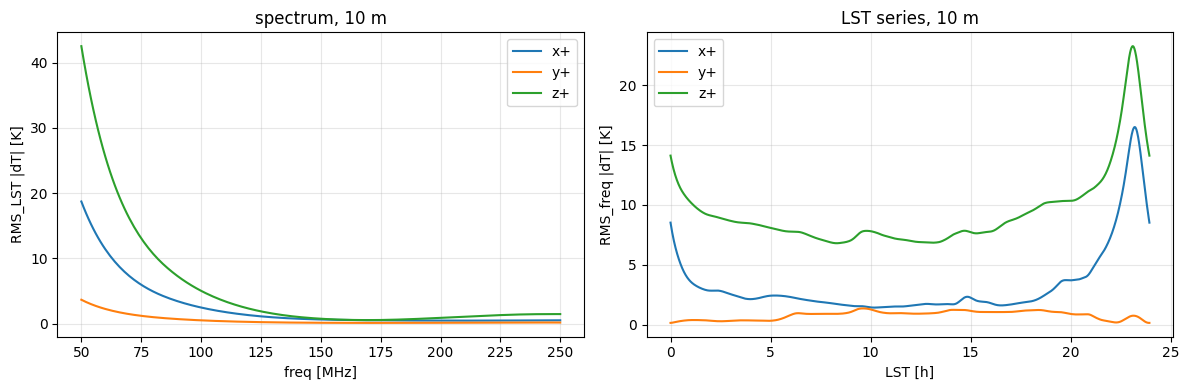

In [4]:
SHIFT = "10"   # magnitude tag
fig, (axf, axt) = plt.subplots(1, 2, figsize=(12, 4))
for axis, c in zip("xyz", ["C0", "C1", "C2"]):
    i = names.index(f"{axis}_p_{SHIFT}")
    axf.plot(freqs, analysis.rms_over_time(delta)[i], c, label=f"{axis}+")
    axt.plot(lst_hours, analysis.rms_over_freq(delta)[i], c, label=f"{axis}+")
axf.set_xlabel("freq [MHz]"); axf.set_ylabel("RMS_LST |dT| [K]"); axf.set_title(f"spectrum, {SHIFT} m")
axt.set_xlabel("LST [h]"); axt.set_ylabel("RMS_freq |dT| [K]"); axt.set_title(f"LST series, {SHIFT} m")
for a in (axf, axt): a.legend(); a.grid(alpha=.3)
fig.tight_layout(); fig.savefig("fig_reductions.pdf"); fig.show()

/tmp/ipykernel_673387/3407070112.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.colorbar(im, label="dT [K]"); fig.tight_layout(); fig.savefig("fig_waterfall.pdf"); fig.show()


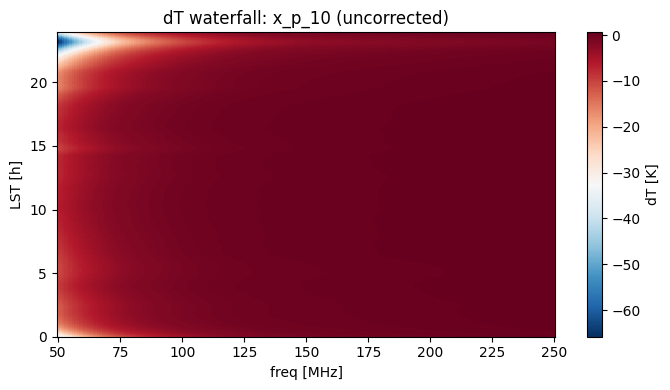

In [5]:
i = names.index(f"x_p_{SHIFT}")
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(freqs, lst_hours, delta[i], shading="auto", cmap="RdBu_r")
ax.set_xlabel("freq [MHz]"); ax.set_ylabel("LST [h]")
ax.set_title(f"dT waterfall: {names[i]} ({MODE})")
fig.colorbar(im, label="dT [K]"); fig.tight_layout(); fig.savefig("fig_waterfall.pdf"); fig.show()